<a href="https://colab.research.google.com/github/matteo-zirilli/ai-projects/blob/main/Riconoscimento_di_fiori_per_un%E2%80%99azienda_AgriTech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch import Tensor
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
import copy
import shutil, zipfile, os, gzip
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
import random

In [2]:
pip install timm

In [3]:
import timm

# FUNCTIONS

Ispezionamento datasets

In [62]:

def inspect_dataset(dataset: ImageFolder):


  """Print a diagnostic summary of an ImageFolder dataset.

    Shows the dataset size, the shape and type of a sample, the classes with
    their index mapping, and the distribution of images across classes (to
    check for class balance).

    Args:
        dataset (ImageFolder): the dataset to inspect. Must be an instance of
            torchvision.datasets.ImageFolder.

    Raises:
        TypeError: if dataset is not an instance of ImageFolder.
    """

  if not isinstance(dataset, ImageFolder):
        raise TypeError(f"Error: the argument must strictly be of type ImageFolder. Received:: {type(dataset).__name__}")

  print(f"Dataset lenght: {len(dataset)} elements")
  print(f"Dataset Shape: {dataset[0][0].shape}")
  print(f"Type of dataset item [0]: {type(dataset[0])}")
  print(f"Tuple length: {len(dataset[0])}")
  print(f"Image type: {type(dataset[0][0])}, dimensione {dataset[0][0].dtype}")
  print(f"Dataset classes: {dataset.classes}")
  print(f"Class-to-index mapping: {dataset.class_to_idx}")
  print(f"Class balance check: \n {Counter(dataset.targets)}")

Ispezionamento Data Loaders

In [64]:
#inspect images, labels

def inspect_loaders(images:Tensor, labels:Tensor):

  """Print the shape and type of a batch of images and their labels.

    Useful to check that a batch drawn from a DataLoader has the expected
    dimensions and dtypes (e.g. float32 images of shape
    (batch, channels, height, width) and int64 labels of shape (batch,)).

    Args:
        images (Tensor): the image batch tensor.
        labels (Tensor): the tensor of corresponding labels.

    Raises:
        TypeError: if images or labels are not instances of torch.Tensor.
    """

  if not isinstance(images, Tensor):
        raise TypeError(f"Error: the 'images' argument must strictly be of type Tensor. Received: {type(images).__name__}")
  if not isinstance(labels, Tensor):
        raise TypeError(f"Error: the 'labels' argument must strictly be of type Tensor. Received: {type(labels).__name__}")

  print(f"Image Shape: {images.shape}")
  print(f"Image Type: {images.dtype}")
  print(f"Label Shape: {labels.shape}")
  print(f"Label type: {labels.dtype}")

Funzione di Denormalizzazione

In [6]:
def denormalize(image_tensor:Tensor, mean:tuple, std:tuple) -> np.ndarray:

  #transforming mean and std in tensor, reshaped to match the standard tensor image (C = 3, H = 224, W = 224)
  std = torch.tensor(std).reshape(-1,1,1)
  mean = torch.tensor(mean).reshape(-1,1,1)
  image_denormalized = image_tensor*std + mean   #inverting the normalization shape (3,224,224) - (C,H,W)
  image_denormalized = image_denormalized.permute(1,2,0)  #shape (224,224,3) - (H,W,C) to align with matplotlibs input standards
  image_denormalized = image_denormalized.detach().cpu().numpy()  #to generalize in case the images are on gpu
  image_denormalized = np.clip(image_denormalized,0,1)



  return image_denormalized

Funzione Plot Immagini

In [65]:
def plot_original_vs_transformed(dataset,transform, mean:tuple, std:tuple, idx, ax_left =None, ax_right= None):

  """Reverse ImageNet-style normalization and return a displayable image.

    Undoes the (pixel - mean) / std normalization by computing
    pixel * std + mean channel-wise, then reorders the axes from (C, H, W)
    to (H, W, C) for matplotlib, moves the tensor to CPU, converts it to a
    numpy array, and clips the values to [0, 1] so it can be shown without
    artifacts. Works whether the input tensor lives on CPU or GPU.

    Args:
        image_tensor (Tensor): a normalized image tensor of shape (C, H, W).
        mean (tuple): the per-channel means used in the original normalization.
        std (tuple): the per-channel standard deviations used in the original
            normalization.

    Returns:
        np.ndarray: the denormalized image as an array of shape (H, W, C),
            with values clipped to [0, 1], ready for matplotlib's imshow.
    """


  image = Image.open(dataset.samples[idx][0])
  image_original = image.convert("RGB")
  image_transformed = denormalize(transform(image_original), mean, std) # transform and denormalize image
  #plot images

  create_image = ax_left is None or ax_right is None

  if create_image:
    fig, (ax_left, ax_right) = plt.subplots(1,2, figsize = (16,16))


  ax_left.imshow(image_original)
  ax_right.imshow(image_transformed)
  ax_left.set_title(f"Dataset Image element {idx+1} - Original")
  ax_right.set_title(f"Dataset Image element {idx+1} - Transformed")
  ax_left.axis("off")
  ax_right.axis("off")

  if create_image:
    plt.show()


In [66]:
def visualise_random_samples(dataset,transform, mean:tuple, std:tuple, n):


  """Display n random samples as original-vs-transformed image pairs.

    Randomly selects n distinct images from the dataset and shows them in an
    n-by-2 grid: the original image on the left and its transformed (and
    denormalized) version on the right, so the effect of the augmentation
    pipeline can be inspected visually. Re-running produces different results,
    since the transform applies random augmentations.

    Args:
        dataset: the dataset to sample from. Must expose a `samples` attribute
            of (path, label) pairs (e.g. torchvision.datasets.ImageFolder).
        transform: the transform pipeline to apply to the right-hand image
            (typically the training transform, including augmentations).
        mean (tuple): the per-channel means used in the normalization, needed
            to denormalize the transformed image for display.
        std (tuple): the per-channel standard deviations used in the
            normalization.
        n (int): the number of random samples to display (one grid row each).
    """

  random_images_idx = random.sample(range(0, len(dataset)), n)

  fig, axes = plt.subplots(nrows=n, ncols=2, figsize = (8,4*n))

  for i,idx in enumerate(random_images_idx):

    plot_original_vs_transformed(dataset,transform, mean, std, idx,axes[i,0], axes[i,1])

  plt.show()



In [9]:
class EarlyStopper():



  """Early stopping helper that tracks the best validation metric and
    stores the corresponding model weights.

    On each call, the current metric value is compared against the best value
    seen so far. If it improves, the best value is updated, a deep copy of the
    model's weights is stored, and the patience counter is reset. If it does
    not improve, the counter is incremented; once it reaches `patience`, the
    call signals that training should stop.

    The direction of "improvement" is controlled by `mode`:
        - 'min': lower is better (e.g. validation loss).
        - 'max': higher is better (e.g. F1 score, accuracy).

    Because the best weights are captured internally, after training the caller
    can restore the best-performing state via `stopper.best_weights`.

    Args:
        patience (int): Number of consecutive non-improving calls tolerated
            before signalling to stop.
        mode (str): Either 'min' or 'max'. Any other value raises ValueError.
        model (nn.Module): The model being trained; used to snapshot its
            weights whenever the metric improves.

    Attributes:
        best_value (float): Best metric value observed so far. Initialised to
            +inf for mode 'min' and -inf for mode 'max'.
        counter (int): Number of consecutive calls without improvement.
        best_weights (dict | None): Deep-copied state_dict of the model at the
            best metric value, or None before the first improvement.

    Raises:
        ValueError: If `mode` is not 'min' or 'max'.

    Returns (from __call__):
        bool: True if training should stop (patience exhausted), False otherwise.

    Example:
        >>> stopper = EarlyStopper(patience=5, mode='max', model=model)
        >>> for epoch in range(num_epochs):
        ...     # ... train and compute val_f1 ...
        ...     if stopper(val_f1):
        ...         break
        >>> model.load_state_dict(stopper.best_weights)
    """


  def __init__(self,patience, mode, model):

    self.patience = patience
    self.mode = mode
    if self.mode not in ('min', 'max'):
      raise ValueError(f"mode must be 'min' or 'max', got {mode!r}")
    if self.mode == 'min':
      best_value = float('inf')
    elif self.mode == 'max':
      best_value = -float('inf')
    else:
      print(f"Mode = {self.mode}: to apply early stopping type 'min or 'max'. Training will be performed with no early stopping mode.")
      best_value = 0

    self.best_value = best_value
    self.counter = 0
    self.model = model
    self.best_weights = copy.deepcopy(self.model.state_dict())

  def __call__(self, metric):
    if self.mode == 'min':
        is_better = metric < self.best_value
    elif self.mode == 'max':
        is_better = metric > self.best_value
    else:
        return False          # mode unknown: continue training

    if is_better:
        self.best_value = metric
        self.best_weights = copy.deepcopy(self.model.state_dict())
        self.counter = 0
        return False          # continue training
    else:
        self.counter += 1
        return self.counter >= self.patience   #patience overcome


Here the user can define the function necessary that wants to use as metric to optimize

F1-Macro function

In [10]:
def f1_macro(y_true, y_pred):
  return f1_score(y_true, y_pred, average='macro')

Training function

In [29]:
#defining train model function
def train_model(model, dl_train, dl_val, criterion, optimizer, dict_metric, metric_name, num_epochs = 1000, device = 'cuda', patience = 5):


  """Train a model with early stopping based on a configurable metric.

    For each epoch, runs a training phase (with weight updates) and a
    validation phase (inference only). Records, per epoch, the average
    training and validation loss and the value of the selected metric,
    computed over the entire validation set. Applies early stopping via an
    EarlyStopper object: if the monitored metric does not improve for a number
    of epochs equal to `patience`, training stops. At the end, the model's
    weights are restored to those of the best epoch according to the metric
    (the model is modified in place).

    The metric used for early stopping is configurable through `dict_metric`
    and `metric_name`, so the same function can optimize F1 macro, accuracy,
    precision, etc. without internal changes.

    Args:
        model (nn.Module): The model to train.
        dl_train (DataLoader): DataLoader for the training data.
        dl_val (DataLoader): DataLoader for the validation data.
        criterion: Loss function (e.g. nn.CrossEntropyLoss). Receives the
            model's raw logits and the integer labels.
        optimizer: Optimizer bound to the model's trainable parameters.
        dict_metric (dict): Registry of available metrics, in the form
            {metric_name: (mode, function)}, where:
                - `mode` is 'max' if higher values are better (e.g. F1,
                  accuracy) or 'min' if lower values are better;
                - `function` is a callable with signature
                  (y_true, y_pred) -> float, receiving two 1D numpy arrays
                  (true labels and predictions) and returning the scalar
                  value of the metric.
            Example: {'f1_macro': ('max', f1_macro)}.
        metric_name (str): Key of `dict_metric` selecting the metric to
            monitor for early stopping.
        num_epochs (int): Maximum number of epochs (a safety cap, normally not
            reached because of early stopping). Default: 1000.
        device (str): Device to run training on ('cuda' or 'cpu').
            Default: 'cuda'.
        patience (int): Number of consecutive epochs without improvement in the
            metric tolerated before stopping. Default: 5.

    Returns:
        dict: A dictionary with three keys, each mapped to the list of
            per-epoch values (one entry per executed epoch):
                - 'train_loss': average training loss;
                - 'val_loss': average validation loss;
                - <metric_name>: value of the monitored metric on validation.

    Note:
        The metric is computed by accumulating the predictions (argmax of the
        logits) and the labels of all validation batches, concatenating them
        into two 1D arrays and passing them to the selected function. The
        validation loss is always computed and recorded as a diagnostic, even
        when early stopping is based on a different metric.

    Example:
        >>> dict_metric = {'f1_macro': ('max', f1_macro)}
        >>> history = train_model(model, dl_train, dl_val, criterion, optimizer,
        ...                       dict_metric=dict_metric, metric_name='f1_macro',
        ...                       patience=5)
        >>> history['f1_macro']   # F1 macro per epoch
    """




  mode, metric = dict_metric[metric_name]
  stopper = EarlyStopper(patience = patience, mode = mode, model = model)
  # definisco le due liste di loss per train e val
  train_losses = []
  val_losses = []
  val_metric = []



  model = model.to(device)      #sposto il modello su gpu


  for epoch in range(num_epochs):



    #############FASE DI TRAINING#############

    model.train()  #modalità training
    running_train_loss = 0.0

    all_preds = []
    all_labels = []

    for images,labels in dl_train:

      #sposto images, labels su device
      images = images.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()           #azzero i gradienti
      labels_pred_train = model(images)              #calcolo l'output
      loss = criterion(labels_pred_train, labels)    #calcolo la loss
      loss.backward()                 #eseguo la backward
      optimizer.step()                #step dell'optimizer

      running_train_loss += loss.item()


    epoch_train_loss = running_train_loss/len(dl_train)
    train_losses.append(epoch_train_loss)


  #############FASE DI VALUTAZIONE#############

    model.eval()   # modalità valutazione
    with torch.no_grad():

        running_val_loss = 0.0

        for images, labels in dl_val:

          images = images.to(device)
          labels = labels.to(device)

          labels_pred_val = model(images)
          loss = criterion(labels_pred_val, labels)
          running_val_loss += loss.item()

          #saving all predictions and labels in two lists, to compute f1-macro
          preds = torch.argmax(labels_pred_val, dim = 1).detach().cpu().numpy()
          labels_cpu = labels.detach().cpu().numpy()
          all_preds.append(preds)
          all_labels.append(labels_cpu)



        epoch_val_loss = running_val_loss/len(dl_val)
        val_losses.append(epoch_val_loss)

    #computing f1
    all_preds_flat  = np.concatenate(all_preds)
    all_labels_flat = np.concatenate(all_labels)
    metric_score = metric(all_labels_flat, all_preds_flat)
    val_metric.append(metric_score)
    #################EARLY STOPPING#####################
    print(f"Epoca {epoch+1}: train_loss = {epoch_train_loss:.4f}, val_loss = {epoch_val_loss:.4f}, Metric {metric_name}  = {metric_score:.4f} \n")
    if stopper(metric_score):
      break



  model.load_state_dict(stopper.best_weights)


  return {'train_loss': train_losses, 'val_loss': val_losses, metric_name: val_metric}

Evaluate Function

In [53]:
def evaluate(model, dl_test, dataset_test,dict_metric,metric_name, device='cuda'):



    """Valuta un modello su un set di test e calcola le metriche di classificazione.

    Esegue il modello in modalità inferenza su tutti i batch del test set,
    ricava le classi predette e le confronta con le etichette
    reali. Restituisce accuracy, report dettagliato per classe e matrice di
    confusione.

    Args:
        model (nn.Module): il modello addestrato da valutare.
        dl_test (DataLoader): DataLoader dei dati di test.
        dataset_test (ImageFolder): dataset di test, usato per ricavare i nomi
            delle classi (dataset_test.classes) come etichette del report.
        device (str): dispositivo su cui eseguire la valutazione ('cuda' o
            'cpu'). Default: 'cuda'.

    Returns:
        tuple:
            accuracy (float): frazione di predizioni corrette sul test set.
            class_report (dict): report con precision, recall, f1-score e support
                per ogni classe, oltre alle medie macro e weighted
                (classification_report con output_dict=True).
            conf_matrix (np.ndarray): matrice di confusione di forma
                (num_classi, num_classi), con le classi vere sulle righe e le
                predette sulle colonne.
    """


    model = model.to(device) # sposto su device
    model.eval()
    all_preds = []
    all_labels = []

    mode, metric = dict_metric[metric_name]

    with torch.no_grad():
        for images, labels in dl_test:

            images = images.to(device) # sposto su device
            labels = labels.to(device)

            labels_pred_test = model(images) #forward
            predicted_labels = torch.argmax(labels_pred_test, dim = 1)   #classi predette

            #passo le previsioni e il test di nuovo a cpu per l'evaluation
            all_preds.append(predicted_labels.cpu())
            all_labels.append(labels.cpu())

    # concateno gli accumulatori in due array completi
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()


    #calcolo metric score
    metric_score = metric(all_labels, all_preds)
    #classification report
    class_report = classification_report(all_labels, all_preds, output_dict=True, target_names= dataset_test.classes)
    #confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return metric_score, class_report, conf_matrix

Plot function

In [69]:
def plot_models_results(results_dict):


  """Plot one curve per metric over epochs on a single figure.

    Takes a dictionary mapping each metric name to its list of per-epoch
    values (e.g. the history returned by train_model: 'train_loss',
    'val_loss', 'f1_macro') and draws each as a labelled line against the
    epoch index, with a legend. Each curve is assigned a random colour.

    Args:
        results_dict (dict): a mapping {metric_name: list_of_values}, where
            each value list has one entry per epoch. All lists are assumed to
            share the same length (the number of epochs).
    """

  colors  = [f"#{random.randint(0, 0xFFFFFF):06x}" for _ in range(len(results_dict))]

  for i,key in enumerate(results_dict.keys()):

    plt.plot(results_dict[key], label = f'{key}', color = colors[i])


  plt.xlabel('Epoch')
  plt.ylabel('Metric')
  plt.title('Metrics Curve')
  plt.legend()


  plt.show()

Heatmap function

In [71]:
def heatmap(conf_matrix, class_names, title=''):

    """Display a confusion matrix as an annotated heatmap.

    Draws the confusion matrix with seaborn, annotating each cell with its
    integer count and labelling both axes with the class names. Rows represent
    the true classes and columns the predicted ones.

    Args:
        conf_matrix: a square confusion matrix (e.g. the output of
            sklearn.metrics.confusion_matrix), where entry [i, j] is the number
            of samples of true class i predicted as class j.
        class_names (list): the class names, in index order, used to label the
            rows (true) and columns (predicted).
        title (str): an optional title for the plot. Defaults to ''.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

##MAIN

ASSEGNAZIONE GPU

In [12]:
#RUNTIME GPU
#assigning to variable device the runtime
torch.manual_seed(17)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


IMPORT DATASET

In [13]:
link = 'https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz'
!curl {link} | tar xz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 60.3M    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknow

ISTANZA MODELLO

In [43]:
model = timm.create_model('resnet18', pretrained=True, num_classes = 2) #two classes for dandelion and daisy
timm_data = timm.data.resolve_model_data_config(model)
timm_data

{'input_size': (3, 224, 224),
 'interpolation': 'bicubic',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'crop_pct': 0.95,
 'crop_mode': 'center'}

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

In [ ]:
model.get_classifier()

Linear(in_features=512, out_features=2, bias=True)

In [44]:
#requires_grad will be false for all parameters, except the last linear layer (Transfer Learning)
for param in model.parameters():

  param.requires_grad = False

for param in model.get_classifier().parameters():
  param.requires_grad = True

In [45]:
#count of trainable paramaters
trainable = sum(param.requires_grad for name, param in model.named_parameters())
trainable_params = (p for p in model.parameters() if p.requires_grad)

TRASFORMAZIONI

In [46]:
#TRANSFORMATION

# normalization values

mean = timm_data['mean']
std = timm_data['std']

#defining trasformation

transform_train = transforms.Compose([

                                        transforms.Resize((224,224)),
                                        transforms.RandomRotation(degrees = 20),
                                        transforms.RandomHorizontalFlip(p=0.5),
                                        transforms.ColorJitter(brightness = 0.8, contrast = 0.5),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean, std)
                                      ])



transform_eval = transforms.Compose([

                                        transforms.Resize((224,224)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean, std)
                                      ])

DATASETS e DATALOADERS

In [47]:
content = '/content/progetto-finale-flowes/'

dataset_train = datasets.ImageFolder(root =  content + 'train', transform = transform_train, is_valid_file=lambda path: not os.path.basename(path).startswith('._'))
dataset_val = datasets.ImageFolder(root = content + 'valid', transform = transform_eval, is_valid_file=lambda path: not os.path.basename(path).startswith('._'))
dataset_test = datasets.ImageFolder(root = content + 'test', transform = transform_eval, is_valid_file=lambda path: not os.path.basename(path).startswith('._'))


dl_train = DataLoader(dataset_train, batch_size = 32, shuffle = True, pin_memory=True)
dl_val = DataLoader(dataset_val, batch_size = 32, shuffle = True, pin_memory=True)
dl_test = DataLoader(dataset_test, batch_size = 32, shuffle = True, pin_memory=True)

images_train, labels_train = next(iter(dl_train))
images_val, labels_val = next(iter(dl_val))
images_test, labels_test = next(iter(dl_test))


In [72]:
print("TRAIN DATASET\n")
inspect_dataset(dataset_train)
print("VAL DATASET\n")
inspect_dataset(dataset_val)
print("TEST DATASET\n")
inspect_dataset(dataset_test)

TRAIN DATASET

Dataset lenght: 1275 elements
Dataset Shape: torch.Size([3, 224, 224])
Type of dataset item [0]: <class 'tuple'>
Tuple length: 2
Image type: <class 'torch.Tensor'>, dimensione torch.float32
Dataset classes: ['daisy', 'dandelion']
Class-to-index mapping: {'daisy': 0, 'dandelion': 1}
Class balance check: 
 Counter({1: 746, 0: 529})
VAL DATASET

Dataset lenght: 364 elements
Dataset Shape: torch.Size([3, 224, 224])
Type of dataset item [0]: <class 'tuple'>
Tuple length: 2
Image type: <class 'torch.Tensor'>, dimensione torch.float32
Dataset classes: ['daisy', 'dandelion']
Class-to-index mapping: {'daisy': 0, 'dandelion': 1}
Class balance check: 
 Counter({1: 201, 0: 163})
TEST DATASET

Dataset lenght: 182 elements
Dataset Shape: torch.Size([3, 224, 224])
Type of dataset item [0]: <class 'tuple'>
Tuple length: 2
Image type: <class 'torch.Tensor'>, dimensione torch.float32
Dataset classes: ['daisy', 'dandelion']
Class-to-index mapping: {'daisy': 0, 'dandelion': 1}
Class balance

The classes are imbalanced, but only slightly. For now I am not applying any measure to weight the classes differently. I will first check the results at a baseline level, and then possibly evaluate whether to apply different weights.

In [73]:
print("TRAIN DATALOADER\n")
inspect_loaders(images_train, labels_train)
print("VAL DATALOADER\n")
inspect_loaders(images_val, labels_val)
print("TEST DATALOADER\n")
inspect_loaders(images_val, labels_val)

TRAIN DATALOADER

Image Shape: torch.Size([32, 3, 224, 224])
Image Type: torch.float32
Label Shape: torch.Size([32])
Label type: torch.int64
VAL DATALOADER

Image Shape: torch.Size([32, 3, 224, 224])
Image Type: torch.float32
Label Shape: torch.Size([32])
Label type: torch.int64
TEST DATALOADER

Image Shape: torch.Size([32, 3, 224, 224])
Image Type: torch.float32
Label Shape: torch.Size([32])
Label type: torch.int64


Images visualisation

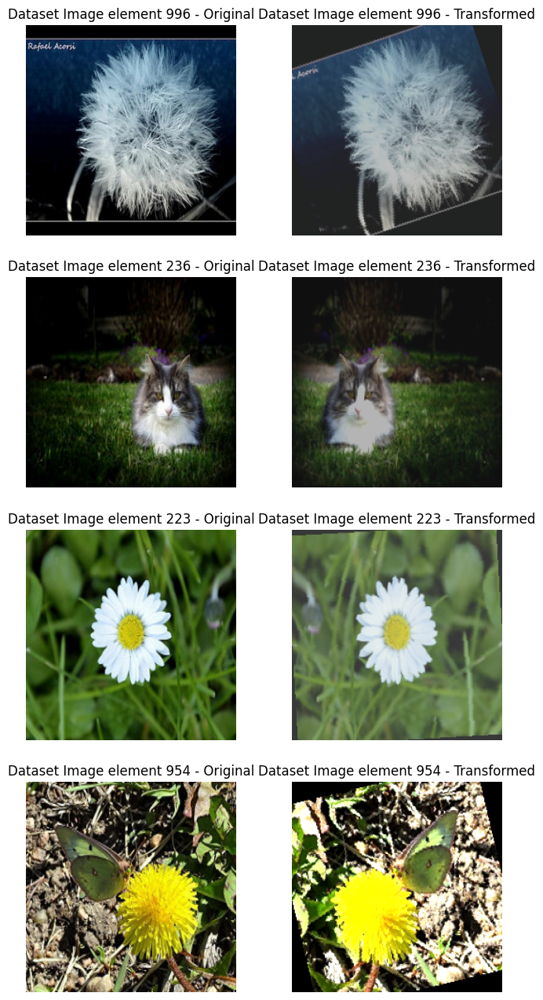

In [ ]:
visualise_random_samples(dataset_train, transform_train, mean, std, 4)

**Data Quality Note — Potential Label Noise**

During manual inspection of the training set, dataset element 954 and element 236 were examined in detail. Element 236 shows a cat as the dominant subject, with no clearly visible flower, this is a likely case of label noise, either a mislabeled image or one where the flower was cropped out of frame. It has been kept in the dataset for the baseline model, since it appears to be an isolated case, but it is flagged as a candidate for removal should it prove to harm validation performance.

More broadly, a manual review of about 30 samples revealed that approximately 13% of images contain an insect or animal on or beside the flower (bee, spider, fly, butterfly). These are not considered label noise: the flower is present and correctly labeled, and such images add realistic difficulty that reflects real field conditions, where pollinators are frequently present. For this reason, they are intentionally retained in the dataset.

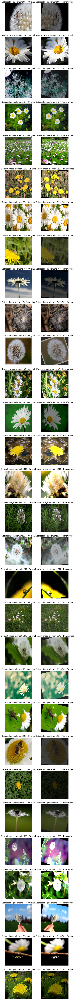

In [ ]:
visualise_random_samples(dataset_train, transform_train, mean, std, 30)

Step di training

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(trainable_params, lr = 0.001)


dict_metric = {'f1-macro':('max', f1_macro)}

In [49]:
results_train = train_model(model, dl_train, dl_val, criterion, optimizer, dict_metric, 'f1-macro', num_epochs = 1000, device = 'cuda', patience = 5)

Epoca 1: train_loss = 0.5757, val_loss = 0.4734, Metric f1-macro  = 0.8552 

Epoca 2: train_loss = 0.4542, val_loss = 0.3903, Metric f1-macro  = 0.8806 

Epoca 3: train_loss = 0.3854, val_loss = 0.3520, Metric f1-macro  = 0.8732 

Epoca 4: train_loss = 0.3659, val_loss = 0.3196, Metric f1-macro  = 0.9113 

Epoca 5: train_loss = 0.3340, val_loss = 0.2897, Metric f1-macro  = 0.9115 

Epoca 6: train_loss = 0.3174, val_loss = 0.2901, Metric f1-macro  = 0.8845 

Epoca 7: train_loss = 0.2923, val_loss = 0.2726, Metric f1-macro  = 0.9140 

Epoca 8: train_loss = 0.2757, val_loss = 0.2588, Metric f1-macro  = 0.8923 

Epoca 9: train_loss = 0.2847, val_loss = 0.2501, Metric f1-macro  = 0.8898 

Epoca 10: train_loss = 0.2591, val_loss = 0.2428, Metric f1-macro  = 0.8923 

Epoca 11: train_loss = 0.2606, val_loss = 0.2279, Metric f1-macro  = 0.9196 

Epoca 12: train_loss = 0.2506, val_loss = 0.2200, Metric f1-macro  = 0.9142 

Epoca 13: train_loss = 0.2534, val_loss = 0.2266, Metric f1-macro  = 0.91

Evaluation on test set

In [55]:
results_eval = evaluate(model, dl_test, dataset_test, dict_metric, 'f1-macro',device='cuda')

In [56]:
results_eval

(0.8928848000495617,
 {'daisy': {'precision': 0.881578947368421,
   'recall': 0.8701298701298701,
   'f1-score': 0.8758169934640523,
   'support': 77.0},
  'dandelion': {'precision': 0.9056603773584906,
   'recall': 0.9142857142857143,
   'f1-score': 0.909952606635071,
   'support': 105.0},
  'accuracy': 0.8956043956043956,
  'macro avg': {'precision': 0.8936196623634558,
   'recall': 0.8922077922077922,
   'f1-score': 0.8928848000495617,
   'support': 182.0},
  'weighted avg': {'precision': 0.8954720800549996,
   'recall': 0.8956043956043956,
   'f1-score': 0.8955106164473323,
   'support': 182.0}},
 array([[67, 10],
        [ 9, 96]]))

# Results Visualisation

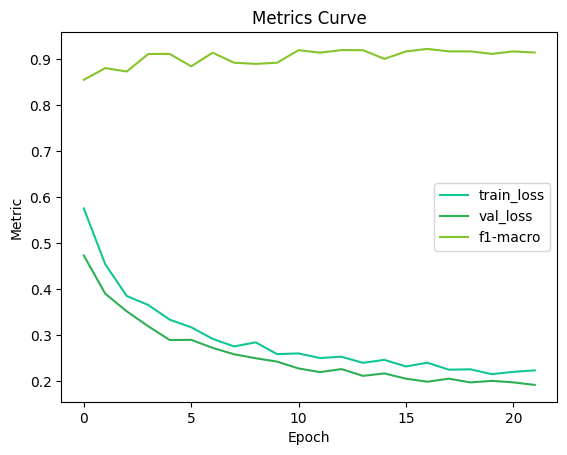

In [51]:
plot_models_results(results_train)

Heatmap

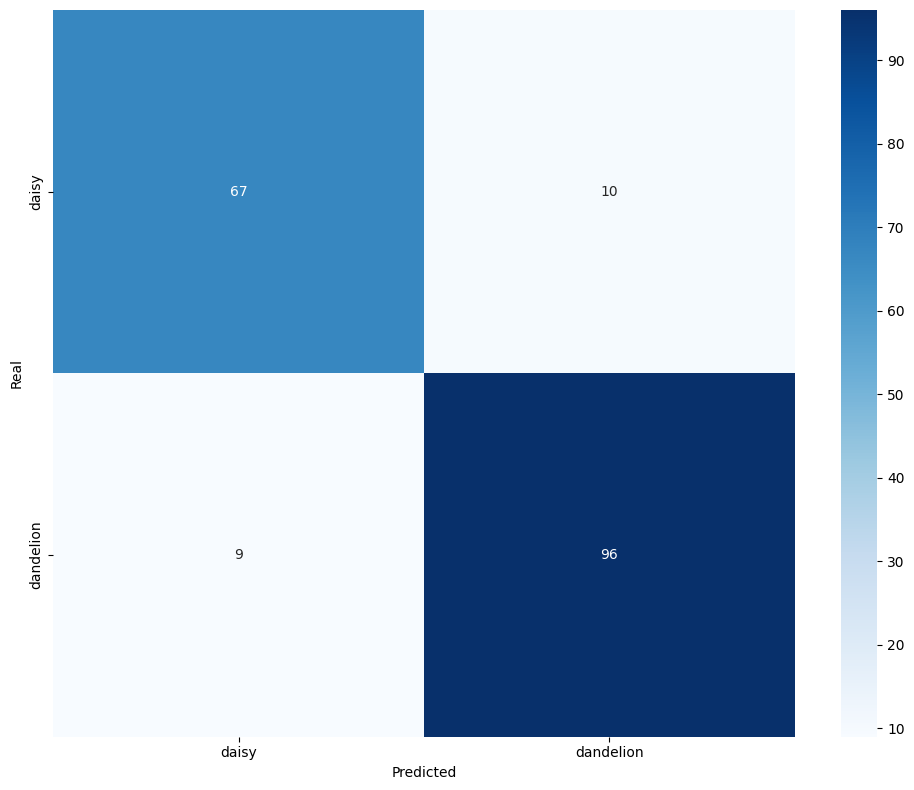

In [61]:
class_names = list(results_eval[1].keys())
class_names = class_names[:-3]

heatmap(results_eval[2], class_names, title='')

# CONCLUSION

# Flower Recognition — Final Analysis

## What we set out to do, and what came out of it

The goal was a working prototype that tells daisies and dandelions apart as reliably as possible, measured by macro F1 on a test set the model never sees during training. The dataset is small, around 1,275 training images, so the whole approach was shaped by that single constraint from the very beginning.

Rather than training a network from scratch (which, with so few images, would almost certainly have failed), we started from a **ResNet-18 already pre-trained on ImageNet** and reused what it had learned. In practice this means the convolutional backbone, the part that already knows how to see edges, textures, shapes and colours, was left frozen, and only a fresh two-class head was trained on top of it. The model was trained with cross-entropy loss and the Adam optimizer, and we stopped early based on the validation macro F1 rather than the loss, because the F1 is the number the project actually cares about.

On the test set (77 daisies and 105 dandelions), the model reached a **macro F1 of about 0.89**, with an accuracy close to 90%. The two classes came out well balanced: daisy sat around 0.88 in F1, dandelion around 0.91. Just as telling is *how* it got things wrong, ten daisies mistaken for dandelions, nine the other way round. The errors are almost symmetric, which means the model isn't quietly favouring the larger class. And because the test score lands right next to the best validation score (about 0.92), we can be fairly confident the model is genuinely generalizing rather than having memorised the validation set.

## What the model does well

The most striking thing is how much came for free from transfer learning. The model was already at roughly 0.86 macro F1 *after the first epoch*, before the head had really been trained at all. That number is the clearest possible evidence that ImageNet's features carry over to flowers: the network didn't need to learn to see, it only needed to learn which of the things it already saw mattered for telling two flowers apart.

The training itself was healthy. Training and validation loss fell together the whole way through, and the validation loss actually stayed a little *below* the training loss, which sounds backwards until you remember that the augmentations (rotations, flips, brightness and contrast changes) only apply during training, so the model was being tested on easier, cleaner images than the ones it was learning from. There was no sign of overfitting anywhere in the curves.

Those same augmentations also buy a degree of real-world robustness, and not by accident. Brightness and contrast jitter push the model to cope with the kind of lighting it would meet in the field, bright noon, overcast skies, shade, dusk, while the rotations and flips make it less fussy about the angle a flower is photographed from. And choosing macro F1 as the yardstick, instead of plain accuracy, kept us honest about the smaller class: accuracy would have let a lazy model coast on the more common dandelions, whereas macro F1 refuses to.


The single biggest caveat is that the test set comes from the same source as the training data. A macro F1 of 0.89 is a fair verdict on images *like the ones we trained on*, it is not a promise about photographs taken in an actual GreenTech field, which might come from drones, overhead angles, industrial lighting, or cameras with completely different resolution.

There's also the dataset itself to be candid about. Looking through the images by hand turned up at least one that is plainly mislabeled, a cat, with no flower in sight, and showed that roughly one in eight images has an insect sitting on or beside the flower. The insects we kept on purpose: bees and spiders on flowers are exactly what a field camera would see, so those images make the model tougher, not weaker. The mislabeled ones are genuine noise, and while a handful won't sink the model, they do slightly muddy both what it learns and how trustworthy the test score is.

Finally, the prototype only knows two flowers, and only knows how to say "one or the other." It has no way to react to an image containing no familiar flower at all, a limitation that wouldn't matter in this exercise but would matter a great deal in anything deployed for real.

## Where we'd go next

If the aim were a higher score, the obvious next move is fine-tuning: gently unfreezing part of the backbone and training it at a very low learning rate, so the features stop being generic ImageNet features and start being flower features. The fact that we never overfit suggests the frozen backbone, not the amount of data, is what's currently holding performance back, which is precisely the situation where fine-tuning tends to pay off.


## In short

The prototype does what it was asked to do. It separates daisies from dandelions with a solid, well-balanced macro F1 of about 0.89, built on a method that is sound, reproducible and honest about its own numbers. Its strengths are efficiency and dependable generalization on data like its own; its main unknown is how it behaves when the world stops looking like the training set. For a controlled prototype these are strong, defensible results, but before anyone trusts it in a field, it needs to be tested on images from that field.